In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from matplotlib.animation import PillowWriter

# Complex Plane Wave Visualization in 2D

$$
    u(\mathbf{r},t) = A e^{i(\mathbf{k} \cdot \mathbf{r} - \omega t)}
$$

The $\mathbf{k}$ points in the direction the plane is travelling.


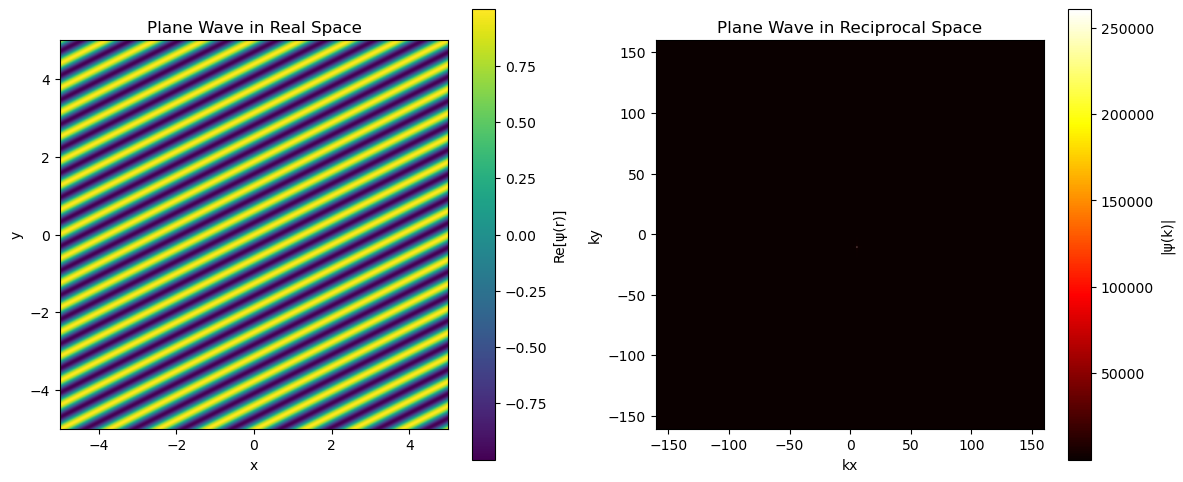

kx=3.141592653589793
ky=4.39822971502571
Peak in reciprocal space at: (kx, ky) = (3.14, 4.40)


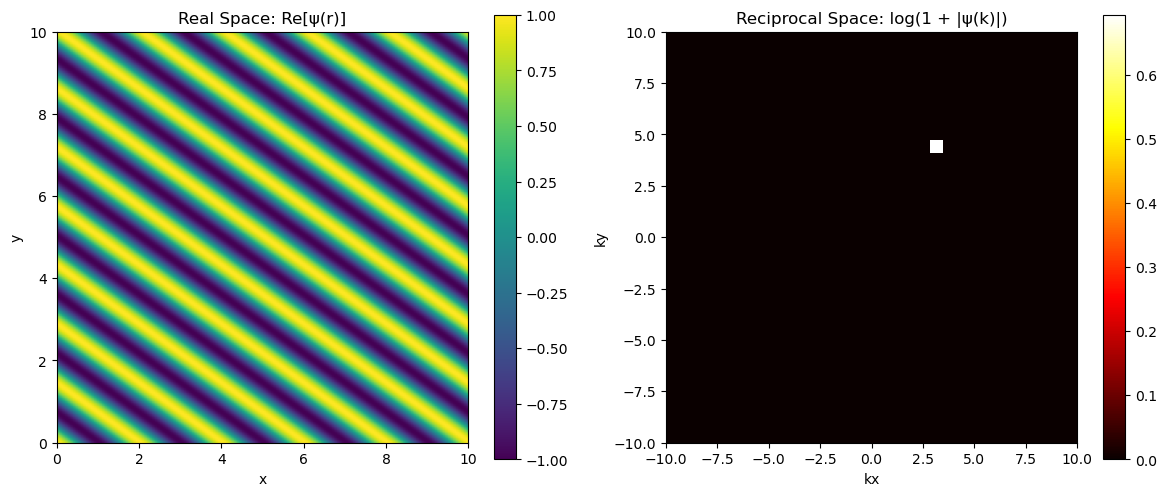

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.fft import fft2, fftshift, fftfreq

# Grid size and domain
N = 256
L = 10.0
x = np.linspace(0, L, N, endpoint=False)
y = np.linspace(0, L, N, endpoint=False)
X, Y = np.meshgrid(x, y)

# Choose wavevector indices that match the FFT grid
n_kx = 5
n_ky = 7
kx = 2 * np.pi * n_kx / L
ky = 2 * np.pi * n_ky / L
print(f"kx={kx}")
print(f"ky={ky}")

# Construct a complex plane wave
psi = np.exp(1j * (kx * X + ky * Y))

# Compute 2D FFT and normalize
psi_k = fftshift(fft2(psi)) / (N * N)
magnitude_k = np.abs(psi_k)

# Frequency values for axis
k_vals = fftshift(fftfreq(N, d=L / N) * 2 * np.pi)

# Find FFT peak for validation
peak_indices = np.unravel_index(np.argmax(magnitude_k), magnitude_k.shape)
peak_kx = k_vals[peak_indices[1]]
peak_ky = k_vals[peak_indices[0]]
print(f"Peak in reciprocal space at: (kx, ky) = ({peak_kx:.2f}, {peak_ky:.2f})")

# Plotting
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Real space wave
im0 = ax[0].imshow(np.real(psi), extent=(0, L, 0, L), cmap='viridis', origin='lower')
ax[0].set_title('Real Space: Re[ψ(r)]')
ax[0].set_xlabel('x')
ax[0].set_ylabel('y')
fig.colorbar(im0, ax=ax[0])

# Reciprocal space (log scale)
#im1 = ax[1].imshow(
#    magnitude_k, 
#    extent=(k_vals[0], k_vals[-1], k_vals[0], k_vals[-1]),
#                   cmap='hot', origin='lower')
dk = k_vals[1] - k_vals[0]
k_range = dk * N
im1 = ax[1].imshow(np.log1p(magnitude_k),
                   extent=(k_vals[0], k_vals[-1], k_vals[0], k_vals[-1]),
                   cmap='hot', origin='lower')
ax[1].set_xlim(0, 6)  # zoom in around the expected peak
ax[1].set_ylim(0, 6)
ax[1].set_title('Reciprocal Space: log(1 + |ψ(k)|)')
ax[1].set_xlabel('kx')
ax[1].set_ylabel('ky')
ax[1].set_xlim(-10,10)
ax[1].set_ylim(-10,10)
fig.colorbar(im1, ax=ax[1])

plt.tight_layout()
plt.show()
